***

## Deep Learning & Generative AI - Exam Practice

## PRACTICAL 4 : Pattern Matching using RBM & DBN

***

#### Objective: To use a **Restricted Boltzmann Machine (RBM)** for learning hidden representations of noisy binary patterns and use a simple **Deep Belief Network (DBN)** for pattern classification.

### Theory Notes:

* **RBM (Restricted Boltzmann Machine):** An unsupervised neural network with a visible layer and a hidden layer.
* **Visible layer:** Represents the input pattern.
* **Hidden layer:** Learns a compact representation of the input.
* **RBM pattern matching:** Patterns can be compared using distances between their hidden representations.
* **DBN (Deep Belief Network):** Formed by stacking multiple RBMs and using the learned features for classification.
* **Greedy layer-wise pretraining:** Each RBM is trained one layer at a time.
* **Hamming distance:** Counts the number of different pixels between two binary patterns.
* In this practical, the patterns **A, H and X** are represented using 5 × 5 binary grids.

***

### 1] import the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import BernoulliRBM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)

### 2] define the original patterns

In [2]:
# 5 x 5 binary patterns
patterns = {
    'A': np.array([
        0,1,1,1,0,
        1,0,0,0,1,
        1,1,1,1,1,
        1,0,0,0,1,
        1,0,0,0,1
    ]),
    'H': np.array([
        1,0,0,0,1,
        1,0,0,0,1,
        1,1,1,1,1,
        1,0,0,0,1,
        1,0,0,0,1
    ]),
    'X': np.array([
        1,0,0,0,1,
        0,1,0,1,0,
        0,0,1,0,0,
        0,1,0,1,0,
        1,0,0,0,1
    ])
}

pattern_names = list(patterns.keys())
class_to_id = {name: i for i, name in enumerate(pattern_names)}
id_to_class = {i: name for name, i in class_to_id.items()}

### 3] display patterns

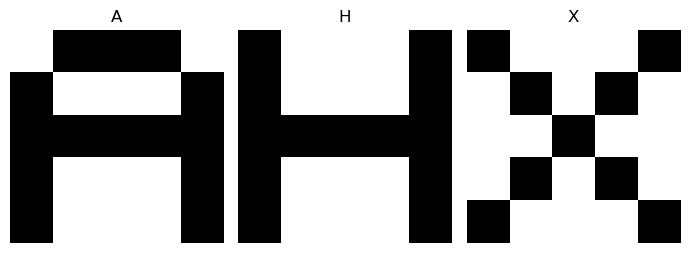

In [13]:
def show_patterns(pattern_list, titles):
    plt.figure(figsize=(7, 3))
    for i, (pattern, title) in enumerate(zip(pattern_list, titles)):
        plt.subplot(1, len(pattern_list), i + 1)
        plt.imshow(pattern.reshape(5, 5), cmap='binary')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_patterns(list(patterns.values()), pattern_names)

### 4] generate controlled noisy samples

Noise is created by flipping a small number of binary pixels.

$x_i^{noisy} = 1 - x_i$

This keeps the noisy patterns recognizable while creating a pattern-matching problem.

In [4]:
rng = np.random.default_rng(42)

def add_noise(pattern):
    noisy = pattern.copy()
    n_flips = rng.choice([0, 1, 2, 3])
    if n_flips > 0:
        pos = rng.choice(len(pattern), n_flips, replace=False)
        noisy[pos] = 1 - noisy[pos]
    return noisy

X, y = [], []
samples_per_class = 150

for class_id, name in enumerate(pattern_names):
    for _ in range(samples_per_class):
        X.append(add_noise(patterns[name]))
        y.append(class_id)

X = np.array(X)
y = np.array(y)

print('Samples:', X.shape[0])
print('Features:', X.shape[1])
print('Classes:', pattern_names)

Samples: 450
Features: 25
Classes: ['A', 'H', 'X']


### 5] RBM concept

An RBM contains a **visible layer** and a **hidden layer**.

Hidden activation probability:

$P(h_j=1|v)=\sigma(b_j+\sum_i v_iw_{ij})$

Visible reconstruction probability:

$P(v_i=1|h)=\sigma(a_i+\sum_j h_jw_{ij})$

where $\sigma(z)=\frac{1}{1+e^{-z}}$ is the sigmoid function.

### 6] train the RBM

In [5]:
# RBM learns hidden features from the noisy patterns
rbm = BernoulliRBM(n_components=12, learning_rate=0.05, batch_size=20, 
                   n_iter=30, random_state=42)

rbm.fit(X)

print('RBM training completed.')

RBM training completed.


### 7] create a controlled noisy pattern A

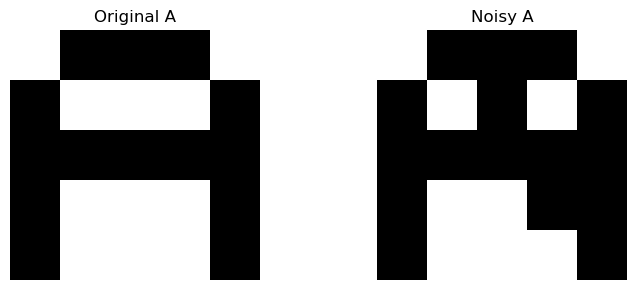

Flipped positions: [7, 18]


In [6]:
original_A = patterns['A'].copy()
noisy_A = original_A.copy()

# Flip two fixed pixels
flipped_positions = [7, 18]
noisy_A[flipped_positions] = 1 - noisy_A[flipped_positions]

show_patterns( [original_A, noisy_A], ['Original A', 'Noisy A'] )

print('Flipped positions:', flipped_positions)

### 8] RBM pattern matching

The noisy input is transformed into the RBM hidden space and compared with the clean prototype patterns.

In [7]:
prototype_matrix = np.array(list(patterns.values()))
prototype_features = rbm.transform(prototype_matrix)

input_features = rbm.transform(noisy_A.reshape(1, -1))[0]

# Euclidean distance in hidden feature space
distances = np.linalg.norm(prototype_features - input_features, axis=1)

match = pattern_names[np.argmin(distances)]

for name, distance in zip(pattern_names, distances):
    print(f'Distance to {name}: {distance:.4f}')

print('\nRBM matched pattern:', match)

Distance to A: 0.0739
Distance to H: 1.3003
Distance to X: 3.2746

RBM matched pattern: A


### 9] display the RBM matching result

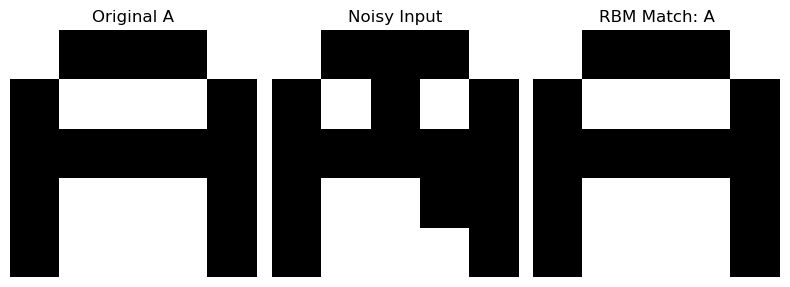

Result verified: noisy A matched with A.


In [8]:
show_patterns( [original_A, noisy_A, patterns[match]],
              ['Original A', 'Noisy Input', f'RBM Match: {match}'] )

if match == 'A':
    print('Result verified: noisy A matched with A.')
else:
    print('Pattern was not matched correctly.')

### 10] hamming-distance verification

Hamming distance counts the number of pixels that are different between two binary patterns.

$d_H(x,y)=\sum_i \mathbf{1}(x_i\neq y_i)$

A smaller distance means a closer pattern match.

In [9]:
for name, prototype in patterns.items():
    distance = np.sum(noisy_A != prototype)
    print(f'Noisy A to {name}: {distance}')

Noisy A to A: 2
Noisy A to H: 7
Noisy A to X: 17


### 11] simple DBN architecture

$x \rightarrow RBM_1 \rightarrow RBM_2 \rightarrow Classifier$

* **RBM 1:** learns lower-level pixel relationships.
* **RBM 2:** learns higher-level features from RBM 1.
* **Logistic Regression:** performs final classification.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# First RBM
rbm_1 = BernoulliRBM( n_components=16, learning_rate=0.05,
                     batch_size=20, n_iter=30, random_state=42 )

# Second RBM
rbm_2 = BernoulliRBM(n_components=10, learning_rate=0.05,
                     batch_size=20, n_iter=30, random_state=42)

# Greedy layer-wise training
features_1 = rbm_1.fit_transform(X_train)
features_2 = rbm_2.fit_transform(features_1)

# Final classifier
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(features_2, y_train)

print('DBN training completed.')

DBN training completed.


### 12] evaluate the DBN

In [11]:
test_features_1 = rbm_1.transform(X_test)
test_features_2 = rbm_2.transform(test_features_1)

predictions = classifier.predict(test_features_2)

accuracy = accuracy_score(y_test, predictions)
confusion = confusion_matrix(y_test, predictions)

print(f'Test Accuracy: {accuracy * 100:.2f}%')
print('\nConfusion Matrix:')
print(confusion)

Test Accuracy: 99.12%

Confusion Matrix:
[[37  0  0]
 [ 1 37  0]
 [ 0  0 38]]


### 13] test the DBN on noisy patterns

In [12]:
controlled_flips = {
    'A': [7, 18],
    'H': [1, 13],
    'X': [2, 23]
}

for actual_name in pattern_names:
    noisy = patterns[actual_name].copy()
    noisy[controlled_flips[actual_name]] = 1 - noisy[controlled_flips[actual_name]]

    f1 = rbm_1.transform(noisy.reshape(1, -1))
    f2 = rbm_2.transform(f1)

    predicted_id = classifier.predict(f2)[0]
    predicted_name = id_to_class[predicted_id]
    confidence = np.max(classifier.predict_proba(f2)[0])

    print(
        f'Actual: {actual_name} | '
        f'Predicted: {predicted_name} | '
        f'Confidence: {confidence:.3f}' )

Actual: A | Predicted: A | Confidence: 0.768
Actual: H | Predicted: H | Confidence: 0.736
Actual: X | Predicted: X | Confidence: 0.986


***

### quick revision:

* **RBM:** Learns hidden representations from input data.
* **Visible layer:** Represents the input pattern.
* **Hidden layer:** Learns useful features.
* **RBM transform:** Converts input into hidden-space features.
* **Pattern matching:** Compare hidden representations using distance.
* **Hamming distance:** Counts different binary pixels.
* **DBN:** Stack of RBMs followed by a classifier.
* **Greedy layer-wise training:** Train RBMs one layer at a time.
* **Classifier:** Logistic Regression is used for final pattern classification.
* **Patterns used:** A, H and X.

***